# Modelo Vectorial de Corrección del Error — VECM
## Teoría y aplicación práctica en Python

---

| Campo | Detalle |
|---|---|
| **Área** | Series de tiempo multivariadas · Econometría aplicada |
| **Nivel** | Maestría en Analítica de Datos |
| **Lenguaje** | Python 3 con `statsmodels` |
| **Datos** | Futuros energéticos NYMEX: gasóleo de calefacción (HO=F) y petróleo crudo (CL=F) |
| **Período** | Enero 2015 – Diciembre 2024 (frecuencia mensual) |

---

> **Propósito:** Integrar la fundamentación teórica del VECM con su implementación práctica
> en Python, aplicando el flujo completo de análisis a datos reales de mercados de energía.

---

## Tabla de contenido

1. Objetivo  
2. Introducción teórica  
3. Fundamento matemático  
4. Librerías necesarias  
5. Carga de datos  
6. Limpieza y preparación  
7. Análisis exploratorio  
8. Pruebas de estacionariedad  
9. Justificación del VECM  
10. Selección de rezagos  
11. Prueba de cointegración de Johansen  
12. Estimación del modelo VECM  
13. Interpretación del modelo  
14. Diagnóstico  
15. Pronóstico  
16. Funciones impulso-respuesta  
17. Conclusiones  
18. Recomendaciones metodológicas  
19. Ejercicios propuestos  


<a id='objetivo'></a>
## 1. Objetivo del cuadernillo

Al finalizar este cuadernillo el estudiante será capaz de:

- **Comprender** la teoría de cointegración y su relación con los modelos VAR y VECM.
- **Aplicar** pruebas de raíz unitaria (ADF, KPSS) para determinar el orden de integración.
- **Ejecutar** la prueba de Johansen para detectar relaciones de cointegración.
- **Estimar** e **interpretar** un modelo VECM en Python usando `statsmodels`.
- **Diagnosticar** la validez del modelo mediante análisis de residuos.
- **Generar** pronósticos e **interpretar** funciones impulso-respuesta.
- **Evaluar** cuándo es apropiado el VECM y cuándo se deben usar alternativas.

---


<a id='teoria'></a>
## 2. Introducción teórica

### 2.1 Series de tiempo multivariadas

Una **serie de tiempo multivariada** es un conjunto de $k$ variables observadas en los mismos
instantes de tiempo $t = 1, 2, \ldots, T$. El objetivo es modelar su evolución conjunta,
capturando tanto las dinámicas individuales como las interdependencias entre ellas.

**Ejemplo de este cuadernillo:** precio del petróleo crudo y precio del gasóleo de calefacción.
Ambos son derivados del mismo mercado energético y se espera que se muevan juntos en el largo plazo.

---

### 2.2 Modelo VAR (Vector Autoregresivo)

El **modelo VAR** extiende la regresión univariada al caso multivariado.
Un VAR de orden $p$ modela cada variable en función de sus propios rezagos y los de las demás:

$$\mathbf{y}_t = \mathbf{c} + \mathbf{A}_1 \mathbf{y}_{t-1} + \cdots + \mathbf{A}_p \mathbf{y}_{t-p} + \boldsymbol{\varepsilon}_t$$

donde $\mathbf{y}_t$ es un vector $k \times 1$, $\mathbf{A}_i$ son matrices $k \times k$ de coeficientes
y $\boldsymbol{\varepsilon}_t$ es el vector de errores.

**Limitación crítica:** El VAR estándar es válido solo cuando todas las variables son
**estacionarias** $I(0)$. Si las series son no estacionarias $I(1)$, estimar un VAR en niveles
produce **regresiones espurias** con estadísticos inflados artificialmente.

---

### 2.3 Cointegración: el concepto clave

**Definición:** Dos o más series $I(1)$ están **cointegradas** si existe una combinación lineal
de ellas que es $I(0)$ (estacionaria).

**Intuición económica:** Aunque cada precio se mueve de forma impredecible, existe una relación
de **equilibrio de largo plazo** que los mantiene vinculados. Cuando se desvían, hay fuerzas
del mercado que los atraen de regreso.

**Formalmente:** Si $\mathbf{y}_t = (y_{1t}, y_{2t})'$ son $I(1)$, existe cointegración
si hay un vector $\boldsymbol{\beta}$ tal que:

$$\boldsymbol{\beta}' \mathbf{y}_t = \beta_1 y_{1t} + \beta_2 y_{2t} \sim I(0)$$

El vector $\boldsymbol{\beta}$ se denomina **vector cointegrante**.

---

### 2.4 El modelo VECM

El **VECM (Vector Error Correction Model)** es la representación apropiada para sistemas
de series $I(1)$ cointegradas. Añade el **término de corrección del error (ECT)** que captura
la velocidad de ajuste al equilibrio de largo plazo.

**El VECM dice que los cambios de hoy dependen de:**
1. Sus propios cambios pasados (dinámica de **corto plazo**).
2. Qué tan lejos está el sistema del equilibrio (**corrección del error**).

---

### 2.5 Corto plazo vs. largo plazo

| Componente | Descripción |
|---|---|
| **Largo plazo** | Relación de equilibrio capturada por el vector cointegrante $\boldsymbol{\beta}$ |
| **Corto plazo** | Dinámica transitoria en los coeficientes $\boldsymbol{\Gamma}_i$ de las diferencias |
| **Corrección del error** | Velocidad de retorno al equilibrio, representada por $\boldsymbol{\alpha}$ |

---

### 2.6 Interpretación del coeficiente $\alpha$ (velocidad de ajuste)

El coeficiente $\alpha_i$ de cada ecuación indica:

- **Signo negativo:** La variable se ajusta hacia el equilibrio (esperado en sistemas estables).
- **Magnitud:** Fracción del desequilibrio que se corrige en cada período.
  Por ejemplo, $\alpha = -0.20$ indica que el 20% del desequilibrio se corrige en un período.
- **Significancia:** Si $\alpha_i \approx 0$ o no es significativo, la variable es **débilmente exógena**
  (no responde activamente al desequilibrio).

---

### 2.7 ¿Cuándo usar VECM?

| Situación | Modelo |
|---|---|
| Series $I(0)$ | VAR en niveles |
| Series $I(1)$ sin cointegración | VAR en primeras diferencias |
| Series $I(1)$ **con cointegración** | **VECM** ✓ |
| Órdenes de integración mixtos | ARDL |

---


<a id='matematica'></a>
## 3. Fundamento matemático

### 3.1 Representación VAR(p)

$$\mathbf{y}_t = \mathbf{c} + \sum_{i=1}^{p} \mathbf{A}_i \mathbf{y}_{t-i} + \boldsymbol{\varepsilon}_t$$

### 3.2 Transformación a VECM

Restando $\mathbf{y}_{t-1}$ de ambos lados y reorganizando se obtiene la **representación VECM**:

$$\Delta \mathbf{y}_t = \mathbf{c} + \mathbf{\Pi} \mathbf{y}_{t-1} + \sum_{i=1}^{p-1} \mathbf{\Gamma}_i \Delta \mathbf{y}_{t-i} + \boldsymbol{\varepsilon}_t$$

| Símbolo | Definición | Dimensión |
|---|---|---|
| $\Delta \mathbf{y}_t$ | Primeras diferencias | $k \times 1$ |
| $\mathbf{\Pi} = \sum_{i=1}^{p} \mathbf{A}_i - \mathbf{I}_k$ | Matriz de largo plazo | $k \times k$ |
| $\mathbf{\Gamma}_i$ | Matrices de dinámica de corto plazo | $k \times k$ |

### 3.3 Descomposición de $\mathbf{\Pi}$

La clave del VECM está en el **rango de la matriz $\mathbf{\Pi}$**:

$$\mathbf{\Pi} = \boldsymbol{\alpha} \boldsymbol{\beta}'$$

| Símbolo | Nombre | Interpretación | Dimensión |
|---|---|---|---|
| $\boldsymbol{\alpha}$ | Matriz de carga | Velocidad de ajuste | $k \times r$ |
| $\boldsymbol{\beta}$ | Matriz cointegrante | Equilibrio de largo plazo | $k \times r$ |
| $r$ | Rango de cointegración | Número de relaciones | $0 < r < k$ |

### 3.4 Casos según el rango de $\mathbf{\Pi}$

| Rango $r$ | Significado | Modelo apropiado |
|---|---|---|
| $r = 0$ | Sin cointegración | VAR en diferencias |
| $0 < r < k$ | $r$ relaciones de cointegración | **VECM** |
| $r = k$ | Todas las series son $I(0)$ | VAR en niveles |

### 3.5 VECM bivariado explícito ($k=2$, $r=1$, $p=2$)

$$\begin{pmatrix} \Delta y_{1t} \\ \Delta y_{2t} \end{pmatrix} = \begin{pmatrix} c_1 \\ c_2 \end{pmatrix} + \begin{pmatrix} \alpha_1 \\ \alpha_2 \end{pmatrix} \underbrace{\left(\beta_1 y_{1,t-1} + \beta_2 y_{2,t-1}\right)}_{ECT_{t-1}} + \begin{pmatrix} \gamma_{11} & \gamma_{12} \\ \gamma_{21} & \gamma_{22} \end{pmatrix} \begin{pmatrix} \Delta y_{1,t-1} \\ \Delta y_{2,t-1} \end{pmatrix} + \begin{pmatrix} \varepsilon_{1t} \\ \varepsilon_{2t} \end{pmatrix}$$

### 3.6 Prueba de Johansen

**Estadístico de la traza:**

$$\lambda_{trace}(r) = -T \sum_{i=r+1}^{k} \ln(1 - \hat{\lambda}_i)$$

Prueba $H_0: \text{rango} = r$ vs. $H_1: \text{rango} > r$

**Estadístico del máximo eigenvalor:**

$$\lambda_{max}(r, r+1) = -T \ln(1 - \hat{\lambda}_{r+1})$$

Prueba $H_0: \text{rango} = r$ vs. $H_1: \text{rango} = r+1$

---


<a id='librerias'></a>
## 4. Librerías necesarias en Python

### 4.1 Instalación

Ejecute la siguiente celda **solo si** las librerías no están instaladas en su entorno.


In [1]:
# Instalacion de librerias (ejecutar solo si es necesario)
# !pip install pandas numpy matplotlib seaborn statsmodels openpyxl scipy yfinance
print("Librerías listas. Si alguna faltaba, reinicie el kernel tras instalar.")


Librerías listas. Si alguna faltaba, reinicie el kernel tras instalar.


### 4.2 Importación de librerías


In [2]:
# === Análisis de datos ===
import pandas as pd
import numpy as np

# === Visualización ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Series de tiempo y VECM ===
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen, select_order
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson

# === Estadística ===
from scipy import stats

# === Datos financieros ===
try:
    import yfinance as yf
    YFINANCE_OK = True
except ImportError:
    YFINANCE_OK = False
    print("ADVERTENCIA: instale yfinance: pip install yfinance")

# === Configuración visual ===
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente.")
print(f"pandas {pd.__version__} | numpy {np.__version__} | statsmodels OK")


Librerías importadas correctamente.
pandas 2.3.3 | numpy 2.4.4 | statsmodels OK


<a id='datos'></a>
## 5. Carga de datos

### Descripción del conjunto de datos

Se utilizan dos series de precios de **futuros energéticos** negociados en el NYMEX:

| Variable | Símbolo | Descripción |
|---|---|---|
| **HeatingOil** | `HO=F` | Futuros de gasóleo de calefacción (USD/galón) |
| **CrudeOil** | `CL=F` | Futuros de petróleo crudo WTI (USD/barril, escalado) |

**Fuente:** Yahoo Finance vía `yfinance`  
**Período:** Enero 2015 – Diciembre 2024  
**Frecuencia base:** Diaria → remuestreada a **mensual**

**Justificación económica:** El gasóleo de calefacción es un derivado del petróleo crudo.
Desde la teoría económica, ambos precios deben mantener una relación de equilibrio de
largo plazo determinada por el proceso de refinación y los márgenes del mercado energético.
Esta es exactamente la condición que el VECM está diseñado para modelar.


In [3]:
# === Descarga de datos con yfinance ===
START   = "2015-01-01"
END     = "2024-12-31"
SYMBOLS = ['HO=F', 'CL=F']

if YFINANCE_OK:
    print(f"Descargando datos ({START} a {END})...")
    raw = yf.download(SYMBOLS, start=START, end=END, auto_adjust=True)['Close']
    raw.columns = ['HeatingOil', 'CrudeOil']
    raw.dropna(inplace=True)
    print(f"Datos crudos: {raw.shape[0]} observaciones diarias")
else:
    raise RuntimeError("Instale yfinance: pip install yfinance")


Descargando datos (2015-01-01 a 2024-12-31)...


[*********************100%***********************]  2 of 2 completed

Datos crudos: 2513 observaciones diarias


In [4]:
# === Inspección inicial ===
print("=" * 55)
print("INSPECCIÓN INICIAL")
print("=" * 55)
print(f"\nDimensiones:     {raw.shape[0]} filas x {raw.shape[1]} columnas")
print(f"Período:         {raw.index[0].date()} → {raw.index[-1].date()}")
print(f"Tipo de índice:  {type(raw.index).__name__}")
print("\nPrimeras 5 filas:")
print(raw.head())
print("\nTipos de datos:")
print(raw.dtypes)
print("\nValores faltantes por columna:")
print(raw.isnull().sum())
print("\nEstadísticas descriptivas (precios en USD):")
print(raw.describe().round(4))


INSPECCIÓN INICIAL

Dimensiones:     2513 filas x 2 columnas
Período:         2015-01-02 → 2024-12-30
Tipo de índice:  DatetimeIndex

Primeras 5 filas:
            HeatingOil  CrudeOil
Date                            
2015-01-02   52.689999    1.7957
2015-01-05   50.040001    1.7492
2015-01-06   47.930000    1.7262
2015-01-07   48.650002    1.6999
2015-01-08   48.790001    1.7110

Tipos de datos:
HeatingOil    float64
CrudeOil      float64
dtype: object

Valores faltantes por columna:
HeatingOil    0
CrudeOil      0
dtype: int64

Estadísticas descriptivas (precios en USD):
       HeatingOil   CrudeOil
count   2513.0000  2513.0000
mean      61.9976     2.0834
std       18.1188     0.7145
min      -37.6300     0.6104
25%       48.5200     1.5796
50%       59.9400     1.9576
75%       74.0400     2.4118
max      123.7000     5.1354


<a id='limpieza'></a>
## 6. Limpieza y preparación de datos

### Decisiones metodológicas

1. **Remuestreo mensual:** Los datos diarios presentan ruido que no es relevante para el análisis
   de largo plazo. Se usa el precio de cierre del último día hábil del mes (`resample('ME').last()`).

2. **Transformación logarítmica:** Los precios de activos financieros son más estables en
   logaritmos, estabilizan la varianza y permiten interpretar diferencias como tasas de crecimiento.

3. **Definición de frecuencia:** Esencial para que `statsmodels` opere correctamente.

4. **Tratamiento de faltantes:** Se eliminan observaciones con datos incompletos.


In [5]:
# === Remuestreo a frecuencia mensual ===
df_monthly = raw.resample('ME').last().dropna()
df_monthly.index.freq = 'ME'

print(f"Observaciones mensuales: {len(df_monthly)}")
print(f"Período: {df_monthly.index[0].strftime('%Y-%m')} → {df_monthly.index[-1].strftime('%Y-%m')}")
print("\nPrimeras 6 filas (precios en USD):")
print(df_monthly.head(6).round(4))


Observaciones mensuales: 120
Período: 2015-01 → 2024-12

Primeras 6 filas (precios en USD):
            HeatingOil  CrudeOil
Date                            
2015-01-31       48.24    1.6863
2015-02-28       49.76    2.2989
2015-03-31       47.60    1.7179
2015-04-30       59.63    1.9763
2015-05-31       60.30    1.9553
2015-06-30       59.47    1.8866


In [6]:
# === Transformación logarítmica ===
df = np.log(df_monthly)
df.columns = ['ln_HeatingOil', 'ln_CrudeOil']

print("Series en logaritmos (primeras 6 filas):")
print(df.head(6).round(4))

# Verificar faltantes
missing = df.isnull().sum()
if missing.sum() == 0:
    print("\n✓ Sin valores faltantes.")
else:
    print(f"\n⚠ Faltantes: {missing.to_dict()} — se eliminan.")
    df.dropna(inplace=True)

print("\nEstadísticas descriptivas (logaritmos):")
print(df.describe().round(4))


Series en logaritmos (primeras 6 filas):
            ln_HeatingOil  ln_CrudeOil
Date                                  
2015-01-31         3.8762       0.5225
2015-02-28         3.9072       0.8324
2015-03-31         3.8628       0.5411
2015-04-30         4.0882       0.6812
2015-05-31         4.0993       0.6705
2015-06-30         4.0855       0.6348

✓ Sin valores faltantes.

Estadísticas descriptivas (logaritmos):
       ln_HeatingOil  ln_CrudeOil
count       120.0000     120.0000
mean          4.0852       0.6817
std           0.3050       0.3416
min           2.9360      -0.3121
25%           3.8810       0.4583
50%           4.0980       0.6752
75%           4.3185       0.8618
max           4.7421       1.5648


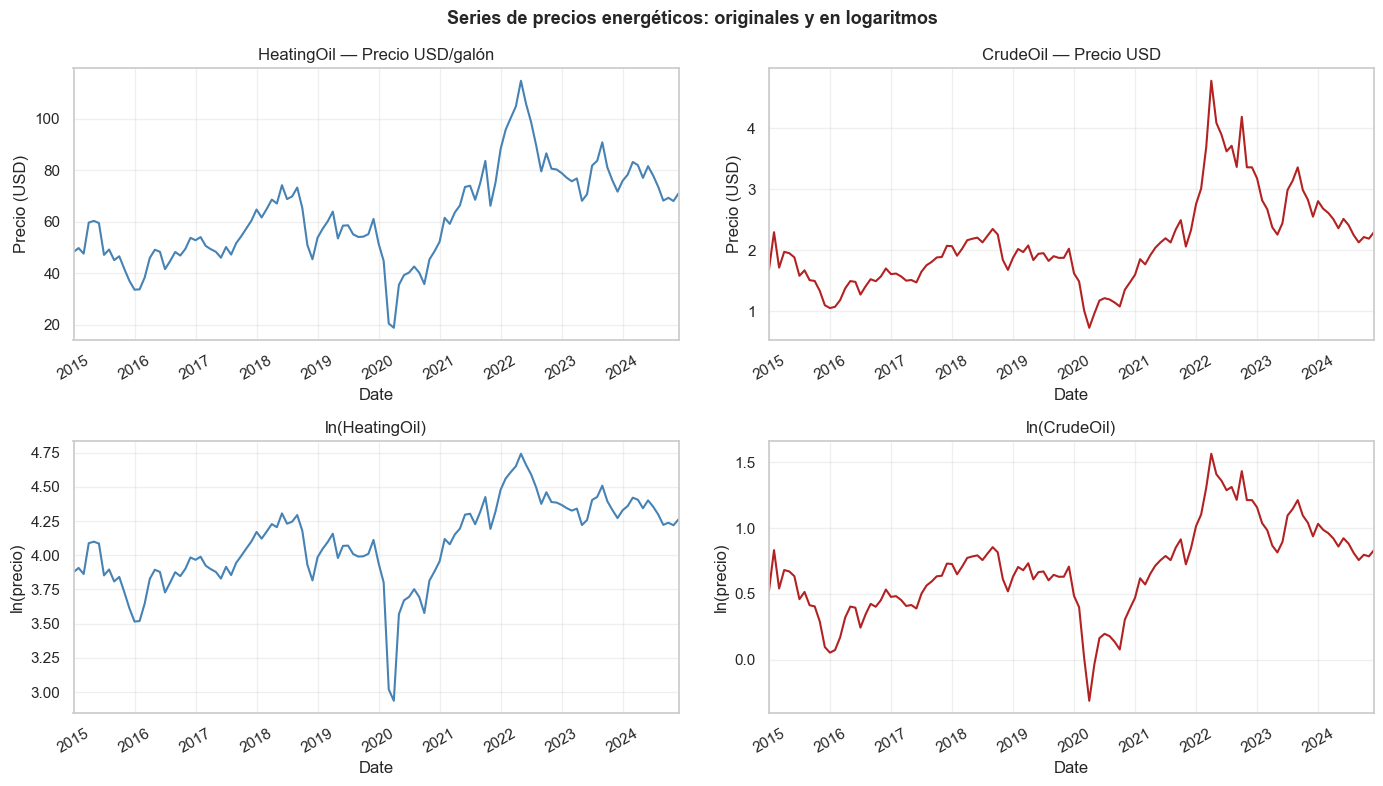


[Interpretación] Ambas series muestran tendencia estocástica creciente con alta
volatilidad. La caída en 2020 corresponde al colapso de demanda por COVID-19.
La transformación logarítmica estabiliza la varianza heterocedástica.


In [7]:
# === Gráficas de las series ===
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df_monthly['HeatingOil'].plot(ax=axes[0,0], color='steelblue', linewidth=1.5)
axes[0,0].set_title('HeatingOil — Precio USD/galón')
axes[0,0].set_ylabel('Precio (USD)')

df_monthly['CrudeOil'].plot(ax=axes[0,1], color='firebrick', linewidth=1.5)
axes[0,1].set_title('CrudeOil — Precio USD')
axes[0,1].set_ylabel('Precio (USD)')

df['ln_HeatingOil'].plot(ax=axes[1,0], color='steelblue', linewidth=1.5)
axes[1,0].set_title('ln(HeatingOil)')
axes[1,0].set_ylabel('ln(precio)')

df['ln_CrudeOil'].plot(ax=axes[1,1], color='firebrick', linewidth=1.5)
axes[1,1].set_title('ln(CrudeOil)')
axes[1,1].set_ylabel('ln(precio)')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Series de precios energéticos: originales y en logaritmos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('series_originales.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n[Interpretación] Ambas series muestran tendencia estocástica creciente con alta")
print("volatilidad. La caída en 2020 corresponde al colapso de demanda por COVID-19.")
print("La transformación logarítmica estabiliza la varianza heterocedástica.")


<a id='exploratorio'></a>
## 7. Análisis exploratorio de series de tiempo


In [8]:
# === Estadísticas descriptivas ===
print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS — SERIES EN LOGARITMOS")
print("=" * 60)
desc = df.describe().T
desc['cv'] = desc['std'] / desc['mean'].abs()
print(desc.round(4))

print("\nAsimetría (skewness):")
print(df.skew().round(4))
print("\nCurtosis excess:")
print(df.kurtosis().round(4))

print("\n[Interpretación] Una asimetría cercana a 0 y curtosis cercana a 0 indicarían")
print("normalidad. En series de precios es común encontrar colas más pesadas.")


ESTADÍSTICAS DESCRIPTIVAS — SERIES EN LOGARITMOS
               count    mean     std     min     25%     50%     75%     max  \
ln_HeatingOil  120.0  4.0852  0.3050  2.9360  3.8810  4.0980  4.3185  4.7421   
ln_CrudeOil    120.0  0.6817  0.3416 -0.3121  0.4583  0.6752  0.8618  1.5648   

                   cv  
ln_HeatingOil  0.0747  
ln_CrudeOil    0.5011  

Asimetría (skewness):
ln_HeatingOil   -0.6884
ln_CrudeOil      0.0184
dtype: float64

Curtosis excess:
ln_HeatingOil    1.5452
ln_CrudeOil      0.1743
dtype: float64

[Interpretación] Una asimetría cercana a 0 y curtosis cercana a 0 indicarían
normalidad. En series de precios es común encontrar colas más pesadas.


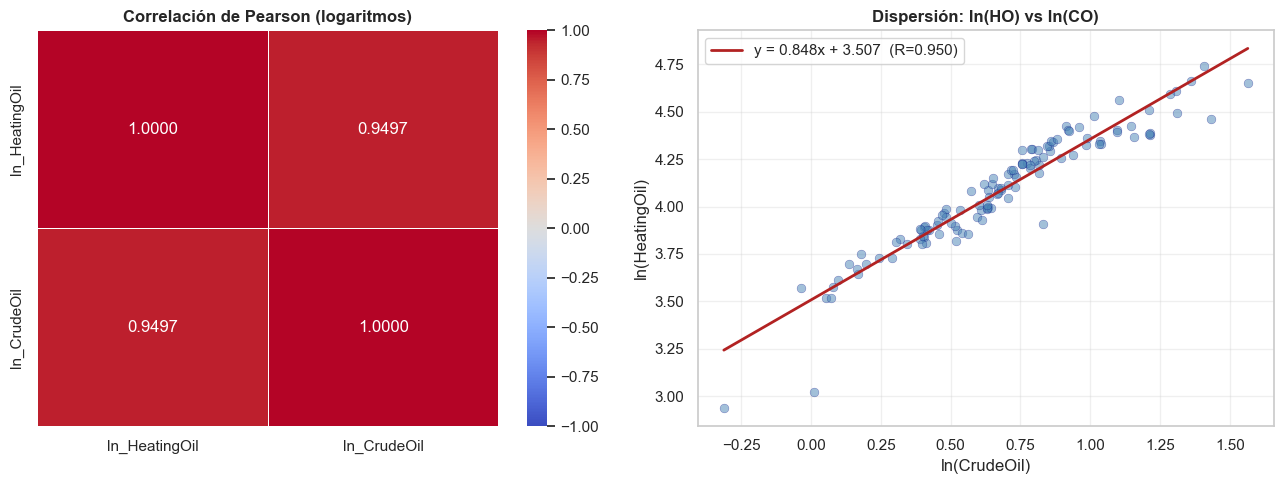


[Interpretación] Correlación de Pearson = 0.9497.
La correlación muy alta sugiere que ambas series comparten una tendencia común.
Un scatter casi lineal es consistente con la hipótesis de cointegración.


In [9]:
# === Matriz de correlación y diagrama de dispersión ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.4f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Correlación de Pearson (logaritmos)', fontweight='bold')

axes[1].scatter(df['ln_CrudeOil'], df['ln_HeatingOil'],
                alpha=0.5, color='steelblue', edgecolors='navy', s=40, linewidth=0.3)
axes[1].set_xlabel('ln(CrudeOil)')
axes[1].set_ylabel('ln(HeatingOil)')
axes[1].set_title('Dispersión: ln(HO) vs ln(CO)', fontweight='bold')
m, b, r, p, se = stats.linregress(df['ln_CrudeOil'], df['ln_HeatingOil'])
xl = np.linspace(df['ln_CrudeOil'].min(), df['ln_CrudeOil'].max(), 100)
axes[1].plot(xl, m*xl+b, color='firebrick', linewidth=2,
             label=f"y = {m:.3f}x + {b:.3f}  (R={r:.3f})")
axes[1].legend()

plt.tight_layout()
plt.savefig('correlacion_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n[Interpretación] Correlación de Pearson = {corr.iloc[0,1]:.4f}.")
print("La correlación muy alta sugiere que ambas series comparten una tendencia común.")
print("Un scatter casi lineal es consistente con la hipótesis de cointegración.")


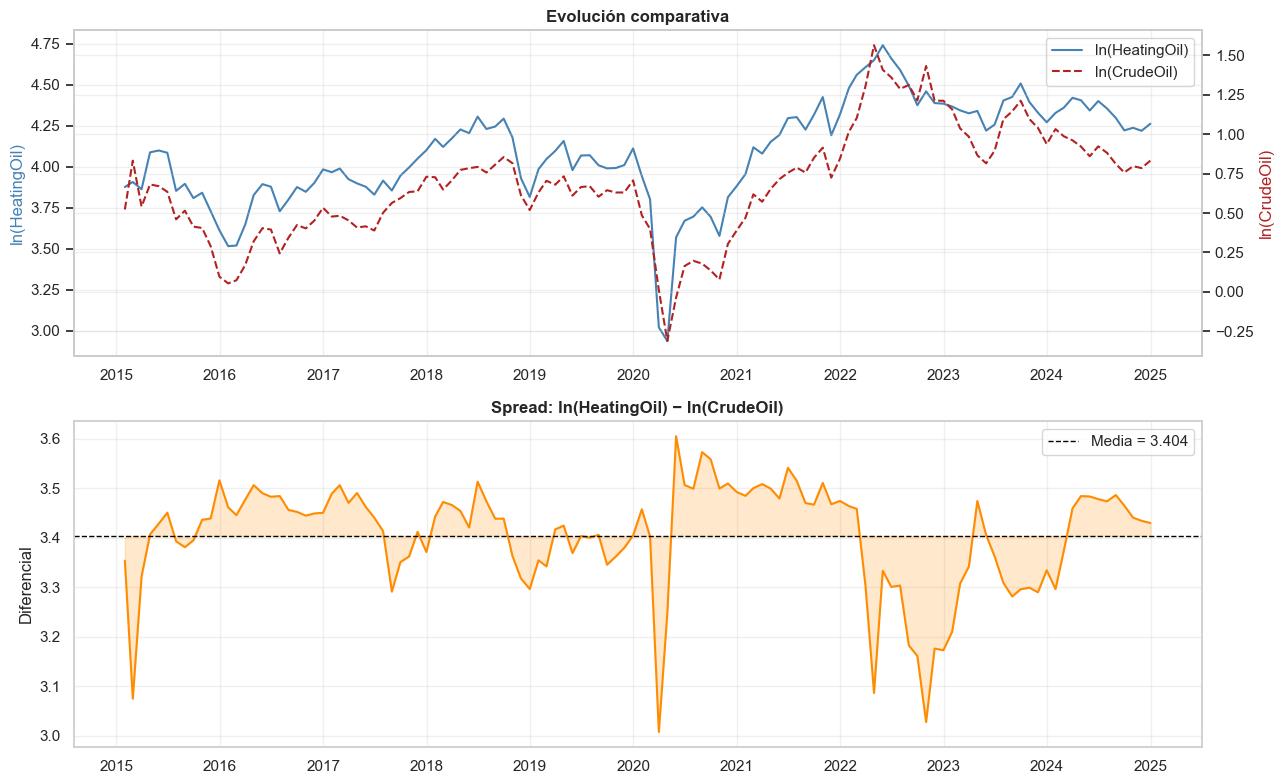


[Interpretación] El spread oscila alrededor de su media (3.4035),
lo que visualmente sugiere una relación de largo plazo entre las series.
Desviación estándar del spread: 0.1088


In [10]:
# === Serie temporal comparativa y spread ===
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

# Eje dual
ax1 = axes[0]
ax2 = ax1.twinx()
l1 = ax1.plot(df.index, df['ln_HeatingOil'],
              color='steelblue', linewidth=1.5, label='ln(HeatingOil)')
l2 = ax2.plot(df.index, df['ln_CrudeOil'],
              color='firebrick', linewidth=1.5, linestyle='--', label='ln(CrudeOil)')
ax1.set_ylabel('ln(HeatingOil)', color='steelblue')
ax2.set_ylabel('ln(CrudeOil)', color='firebrick')
lns = l1 + l2
ax1.legend(lns, [l.get_label() for l in lns], loc='upper right')
ax1.set_title('Evolución comparativa', fontweight='bold')

# Spread
spread = df['ln_HeatingOil'] - df['ln_CrudeOil']
axes[1].plot(spread.index, spread, color='darkorange', linewidth=1.5)
axes[1].axhline(spread.mean(), color='black', linestyle='--', linewidth=1,
               label=f"Media = {spread.mean():.3f}")
axes[1].fill_between(spread.index, spread, spread.mean(), alpha=0.2, color='darkorange')
axes[1].set_title('Spread: ln(HeatingOil) − ln(CrudeOil)', fontweight='bold')
axes[1].set_ylabel('Diferencial')
axes[1].legend()

plt.tight_layout()
plt.savefig('series_comparativas.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n[Interpretación] El spread oscila alrededor de su media ({spread.mean():.4f}),")
print("lo que visualmente sugiere una relación de largo plazo entre las series.")
print(f"Desviación estándar del spread: {spread.std():.4f}")


<a id='estacionariedad'></a>
## 8. Pruebas de estacionariedad

### Prueba ADF (Augmented Dickey-Fuller)

- $H_0$: La serie tiene raíz unitaria (no estacionaria)
- $H_1$: La serie es estacionaria
- **Regla:** p-valor $< 0.05$ → rechazar $H_0$ (estacionaria)

### Prueba KPSS

- $H_0$: La serie es estacionaria
- $H_1$: Raíz unitaria
- **Regla:** p-valor $< 0.05$ → rechazar $H_0$ (no estacionaria)

Las dos pruebas se **complementan**: ADF y KPSS con conclusiones concordantes
dan mayor certeza sobre el orden de integración.


In [11]:
# === Funciones auxiliares para pruebas de raíz unitaria ===

def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC', regression='ct')
    stat, pval, n_lags = result[0], result[1], result[2]
    cv1, cv5, cv10 = result[4]['1%'], result[4]['5%'], result[4]['10%']
    decision = 'ESTACIONARIA' if pval < 0.05 else 'NO ESTACIONARIA'
    print(f"\n  ADF: {name}")
    print(f"    Estadístico: {stat:.4f}  |  p-valor: {pval:.4f}  |  Rezagos: {n_lags}")
    print(f"    Valores críticos: 1%={cv1:.3f}  5%={cv5:.3f}  10%={cv10:.3f}")
    print(f"    Decisión (α=5%): {decision}")
    return pval

def kpss_test(series, name):
    stat, pval, n_lags, crit = kpss(series.dropna(), regression='ct', nlags='auto')
    decision = 'NO ESTACIONARIA' if pval < 0.05 else 'ESTACIONARIA'
    print(f"\n  KPSS: {name}")
    print(f"    Estadístico: {stat:.4f}  |  p-valor: {pval:.4f}")
    print(f"    Decisión (α=5%): {decision}")
    return pval


In [12]:
print("=" * 60)
print("PRUEBAS EN NIVELES")
print("=" * 60)
p_adf_ho    = adf_test(df['ln_HeatingOil'], 'ln(HeatingOil)')
p_adf_co    = adf_test(df['ln_CrudeOil'],   'ln(CrudeOil)')
print("\n" + "=" * 60)
p_kpss_ho   = kpss_test(df['ln_HeatingOil'], 'ln(HeatingOil)')
p_kpss_co   = kpss_test(df['ln_CrudeOil'],   'ln(CrudeOil)')

print("\n" + "=" * 60)
print("RESUMEN — NIVELES")
print("=" * 60)
res_niv = pd.DataFrame({
    'Serie':          ['ln(HeatingOil)', 'ln(CrudeOil)'],
    'ADF p-val':      [round(p_adf_ho, 4), round(p_adf_co, 4)],
    'ADF Decisión':   ['No estac.' if p_adf_ho>0.05 else 'Estac.',
                       'No estac.' if p_adf_co>0.05 else 'Estac.'],
    'KPSS p-val':     [round(p_kpss_ho, 4), round(p_kpss_co, 4)],
    'KPSS Decisión':  ['No estac.' if p_kpss_ho<0.05 else 'Estac.',
                       'No estac.' if p_kpss_co<0.05 else 'Estac.']
})
print(res_niv.to_string(index=False))


PRUEBAS EN NIVELES

  ADF: ln(HeatingOil)
    Estadístico: -2.8895  |  p-valor: 0.1660  |  Rezagos: 2
    Valores críticos: 1%=-4.038  5%=-3.449  10%=-3.149
    Decisión (α=5%): NO ESTACIONARIA

  ADF: ln(CrudeOil)
    Estadístico: -2.7897  |  p-valor: 0.2007  |  Rezagos: 1
    Valores críticos: 1%=-4.038  5%=-3.448  10%=-3.149
    Decisión (α=5%): NO ESTACIONARIA


  KPSS: ln(HeatingOil)
    Estadístico: 0.1104  |  p-valor: 0.1000
    Decisión (α=5%): ESTACIONARIA

  KPSS: ln(CrudeOil)
    Estadístico: 0.1041  |  p-valor: 0.1000
    Decisión (α=5%): ESTACIONARIA

RESUMEN — NIVELES
         Serie  ADF p-val ADF Decisión  KPSS p-val KPSS Decisión
ln(HeatingOil)     0.1660    No estac.         0.1        Estac.
  ln(CrudeOil)     0.2007    No estac.         0.1        Estac.


In [13]:
# === Pruebas en primeras diferencias ===
df_diff = df.diff().dropna()

print("=" * 60)
print("PRUEBAS EN PRIMERAS DIFERENCIAS")
print("=" * 60)
p_adf_dho = adf_test(df_diff['ln_HeatingOil'], 'Δln(HeatingOil)')
p_adf_dco = adf_test(df_diff['ln_CrudeOil'],   'Δln(CrudeOil)')
print("\n")
p_kpss_dho = kpss_test(df_diff['ln_HeatingOil'], 'Δln(HeatingOil)')
p_kpss_dco = kpss_test(df_diff['ln_CrudeOil'],   'Δln(CrudeOil)')

print("\n" + "=" * 60)
print("CONCLUSIÓN SOBRE ORDEN DE INTEGRACIÓN")
print("=" * 60)
I1 = (p_adf_dho < 0.05 and p_adf_dco < 0.05)
if I1:
    print("\n  ✓ Las diferencias son estacionarias.")
    print("  → Ambas series son I(1).")
    print("  → Se puede proceder con la prueba de Johansen.")
else:
    print("\n  ⚠ Verificar individualmente cada serie.")
I1_confirmed = I1


PRUEBAS EN PRIMERAS DIFERENCIAS

  ADF: Δln(HeatingOil)
    Estadístico: -7.0993  |  p-valor: 0.0000  |  Rezagos: 3
    Valores críticos: 1%=-4.040  5%=-3.449  10%=-3.150
    Decisión (α=5%): ESTACIONARIA

  ADF: Δln(CrudeOil)
    Estadístico: -10.4357  |  p-valor: 0.0000  |  Rezagos: 0
    Valores críticos: 1%=-4.038  5%=-3.448  10%=-3.149
    Decisión (α=5%): ESTACIONARIA



  KPSS: Δln(HeatingOil)
    Estadístico: 0.0409  |  p-valor: 0.1000
    Decisión (α=5%): ESTACIONARIA

  KPSS: Δln(CrudeOil)
    Estadístico: 0.0528  |  p-valor: 0.1000
    Decisión (α=5%): ESTACIONARIA

CONCLUSIÓN SOBRE ORDEN DE INTEGRACIÓN

  ✓ Las diferencias son estacionarias.
  → Ambas series son I(1).
  → Se puede proceder con la prueba de Johansen.


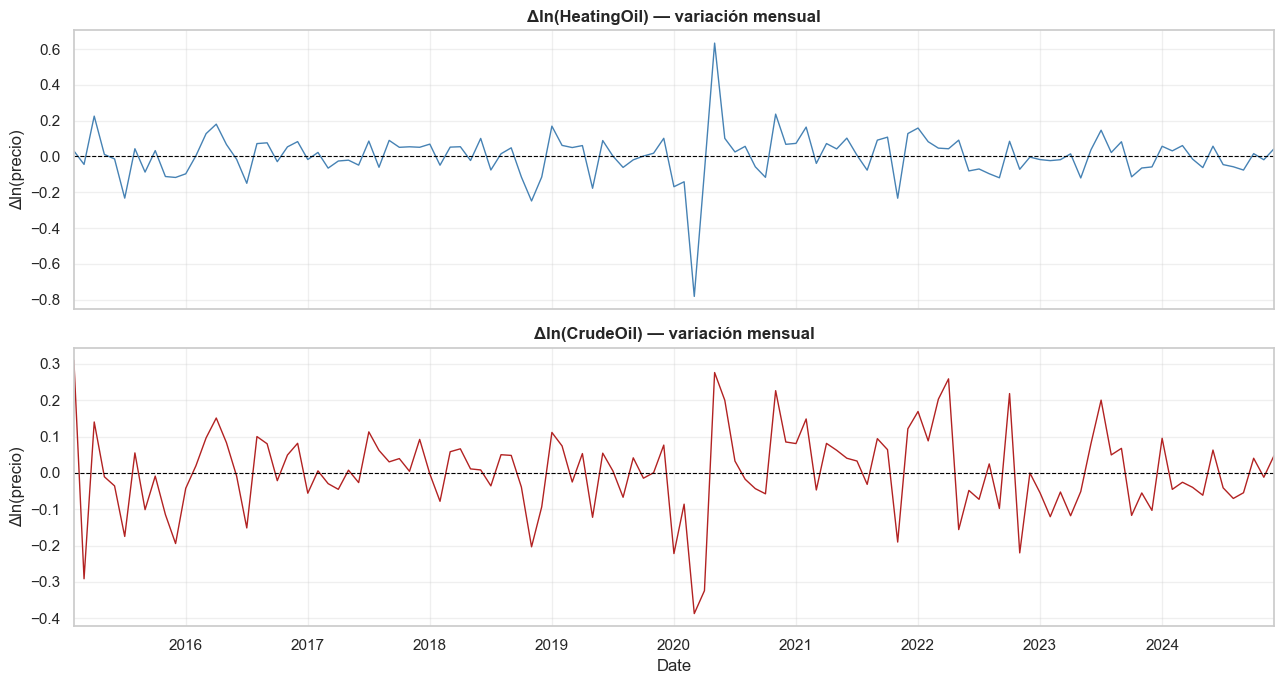


[Interpretación] Las series diferenciadas oscilan alrededor de cero sin tendencia
ni estructura sistemática, confirmando visualmente que son I(0).
Esto refuerza que las series en niveles son I(1).


In [14]:
# === Gráficas de las series diferenciadas ===
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

df_diff['ln_HeatingOil'].plot(ax=axes[0], color='steelblue', linewidth=1)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Δln(HeatingOil) — variación mensual', fontweight='bold')
axes[0].set_ylabel('Δln(precio)')

df_diff['ln_CrudeOil'].plot(ax=axes[1], color='firebrick', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Δln(CrudeOil) — variación mensual', fontweight='bold')
axes[1].set_ylabel('Δln(precio)')

plt.tight_layout()
plt.savefig('series_diferenciadas.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n[Interpretación] Las series diferenciadas oscilan alrededor de cero sin tendencia")
print("ni estructura sistemática, confirmando visualmente que son I(0).")
print("Esto refuerza que las series en niveles son I(1).")


<a id='justificacion'></a>
## 9. Justificación del uso del VECM


In [15]:
print("=" * 65)
print("VERIFICACIÓN DE PRERREQUISITOS PARA EL VECM")
print("=" * 65)

print("\n1. ¿Son las series I(1)?")
if I1_confirmed:
    print("   ✓ Sí — ambas son I(1): no estacionarias en niveles, estacionarias en diferencias.")
else:
    print("   ⚠ No confirmado. Revise los resultados de estacionariedad.")

print("\n2. ¿Tienen la misma frecuencia y período?")
print("   ✓ Sí — ambas son mensuales, mismo período 2015-2024.")

print("\n3. ¿Existe justificación económica para cointegración?")
print("   ✓ Sí — el gasóleo de calefacción (HO) es derivado del petróleo crudo (CO).")
print("     Se espera un equilibrio de largo plazo por la estructura del mercado energético.")

print("\n4. ¿Se verifica cointegración formalmente?")
print("   → Pendiente: se realizará la prueba de Johansen en la sección siguiente.")

print("\n" + "=" * 65)
print("ÁRBOL DE DECISIÓN PARA MODELOS MULTIVARIADOS")
print("=" * 65)
print("""
    ¿Son todas las series estacionarias I(0)?
    ├── SÍ  → VAR en niveles
    └── NO  ¿Son todas I(1)?
        ├── NO (mixtas)  → ARDL
        └── SÍ  ¿Existe cointegración?
            ├── NO  → VAR en primeras diferencias
            └── SÍ  → VECM  ← nuestro camino
""")


VERIFICACIÓN DE PRERREQUISITOS PARA EL VECM

1. ¿Son las series I(1)?
   ✓ Sí — ambas son I(1): no estacionarias en niveles, estacionarias en diferencias.

2. ¿Tienen la misma frecuencia y período?
   ✓ Sí — ambas son mensuales, mismo período 2015-2024.

3. ¿Existe justificación económica para cointegración?
   ✓ Sí — el gasóleo de calefacción (HO) es derivado del petróleo crudo (CO).
     Se espera un equilibrio de largo plazo por la estructura del mercado energético.

4. ¿Se verifica cointegración formalmente?
   → Pendiente: se realizará la prueba de Johansen en la sección siguiente.

ÁRBOL DE DECISIÓN PARA MODELOS MULTIVARIADOS

    ¿Son todas las series estacionarias I(0)?
    ├── SÍ  → VAR en niveles
    └── NO  ¿Son todas I(1)?
        ├── NO (mixtas)  → ARDL
        └── SÍ  ¿Existe cointegración?
            ├── NO  → VAR en primeras diferencias
            └── SÍ  → VECM  ← nuestro camino



<a id='rezagos'></a>
## 10. Selección del número óptimo de rezagos

Se utilizan cuatro criterios de información para determinar el orden $p$ del VAR equivalente.
El número de rezagos del VECM es $p-1$ (el VECM trabaja con diferencias).

| Criterio | Penalización | Tendencia |
|---|---|---|
| **AIC** (Akaike) | Moderada | Sobreestima ligeramente |
| **BIC** (Bayesian/Schwarz) | Fuerte | Parsimonia |
| **HQIC** (Hannan-Quinn) | Intermedia | Balance |
| **FPE** (Final Pred. Error) | Similar a AIC | Error de pronóstico |

**Regla práctica:** Cuando AIC y BIC difieren, el BIC suele ser preferible en muestras pequeñas
(parsimonia). En muestras grandes, el AIC captura mejor la dinámica completa.


In [16]:
print("=" * 60)
print("SELECCIÓN DE REZAGOS ÓPTIMOS")
print("=" * 60)

lag_sel = select_order(df, maxlags=12, deterministic='co')
print("\nTabla de criterios de información:")
print(lag_sel.summary())

print(f"\nRezago óptimo AIC:  {lag_sel.aic}")
print(f"Rezago óptimo BIC:  {lag_sel.bic}")
print(f"Rezago óptimo HQIC: {lag_sel.hqic}")
print(f"Rezago óptimo FPE:  {lag_sel.fpe}")

OPT_LAG      = max(1, lag_sel.bic)
OPT_LAG_VECM = max(1, OPT_LAG - 1)

print(f"\nRezago seleccionado (BIC):  p = {OPT_LAG} para el VAR")
print(f"→ k_ar_diff = {OPT_LAG_VECM} para el VECM (p-1 diferencias)")


SELECCIÓN DE REZAGOS ÓPTIMOS

Tabla de criterios de información:
 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -9.649     -9.449*   6.452e-05     -9.568*
1       -9.647      -9.347   6.464e-05      -9.525
2      -9.665*      -9.265  6.353e-05*      -9.503
3       -9.601      -9.101   6.775e-05      -9.398
4       -9.620      -9.021   6.649e-05      -9.377
5       -9.555      -8.856   7.103e-05      -9.272
6       -9.514      -8.715   7.414e-05      -9.190
7       -9.456      -8.557   7.870e-05      -9.092
8       -9.396      -8.397   8.380e-05      -8.991
9       -9.331      -8.232   8.971e-05      -8.885
10      -9.285      -8.086   9.429e-05      -8.799
11      -9.232      -7.933   9.982e-05      -8.705
12      -9.199      -7.800   0.0001037      -8.631
--------------------------------------------------

Rezago óptimo AIC:  2
Rezago óptimo BIC:  0
Rezago óptimo HQIC: 0
R

<a id='johansen'></a>
## 11. Prueba de cointegración de Johansen

La prueba de Johansen determina el número de relaciones de cointegración $r$ en el sistema.
Se aplica a las series **en niveles** (no diferenciadas).

### Especificación determinística

Para datos de precios en logaritmos se usa **constante dentro de la relación cointegrante**
(`det_order=0`), que equivale al caso más común en aplicaciones con precios financieros.

### Secuencia de hipótesis (estadístico de traza)

| Paso | $H_0$ | $H_1$ | Regla |
|---|---|---|---|
| 1 | $r = 0$ | $r \geq 1$ | Si traza $>$ VC$_{5\%}$: rechazar, hay cointegración |
| 2 | $r \leq 1$ | $r \geq 2$ | Si traza $>$ VC$_{5\%}$: rechazar |

Se para cuando no se puede rechazar $H_0$. El rango final es el último $r$ rechazado + 1.


In [17]:
# === Prueba de Johansen ===
johansen = coint_johansen(df, det_order=0, k_ar_diff=OPT_LAG_VECM)
k = df.shape[1]

print("=" * 70)
print("ESTADÍSTICO DE LA TRAZA")
print("=" * 70)
print(f"\n{"H0":>10} | {"Traza":>9} | {"CV 90%":>7} | {"CV 95%":>7} | {"CV 99%":>7} | {"Decisión":>14}")
print("-" * 70)
coint_rank = 0
for i in range(k):
    ts   = johansen.lr1[i]
    cv90 = johansen.cvt[i, 0]
    cv95 = johansen.cvt[i, 1]
    cv99 = johansen.cvt[i, 2]
    h0   = f"r = 0" if i == 0 else f"r <= {i}"
    dec  = "Rechazar H₀" if ts > cv95 else "No rechazar H₀"
    if ts > cv95:
        coint_rank = i + 1
    print(f"{h0:>10} | {ts:>9.4f} | {cv90:>7.4f} | {cv95:>7.4f} | {cv99:>7.4f} | {dec:>16}")

print("\n" + "=" * 70)
print("ESTADÍSTICO DEL MÁXIMO EIGENVALOR")
print("=" * 70)
print(f"\n{"H0":>10} | {"Max-Eig":>9} | {"CV 90%":>7} | {"CV 95%":>7} | {"CV 99%":>7} | {"Decisión":>14}")
print("-" * 70)
for i in range(k):
    es   = johansen.lr2[i]
    cv90 = johansen.cvm[i, 0]
    cv95 = johansen.cvm[i, 1]
    cv99 = johansen.cvm[i, 2]
    h0   = f"r = {i}"
    dec  = "Rechazar H₀" if es > cv95 else "No rechazar H₀"
    print(f"{h0:>10} | {es:>9.4f} | {cv90:>7.4f} | {cv95:>7.4f} | {cv99:>7.4f} | {dec:>16}")

print(f"\nRango de cointegración estimado: r = {coint_rank}")


ESTADÍSTICO DE LA TRAZA

        H0 |     Traza |  CV 90% |  CV 95% |  CV 99% |       Decisión
----------------------------------------------------------------------
     r = 0 |   40.0318 | 13.4294 | 15.4943 | 19.9349 |      Rechazar H₀
    r <= 1 |    3.4934 |  2.7055 |  3.8415 |  6.6349 |   No rechazar H₀

ESTADÍSTICO DEL MÁXIMO EIGENVALOR

        H0 |   Max-Eig |  CV 90% |  CV 95% |  CV 99% |       Decisión
----------------------------------------------------------------------
     r = 0 |   36.5383 | 12.2971 | 14.2639 | 18.5200 |      Rechazar H₀
     r = 1 |    3.4934 |  2.7055 |  3.8415 |  6.6349 |   No rechazar H₀

Rango de cointegración estimado: r = 1


In [18]:
print("=" * 65)
print("INTERPRETACIÓN DE LA PRUEBA DE JOHANSEN")
print("=" * 65)

if coint_rank == 0:
    print("""
    RESULTADO: NO se detectó cointegración (r = 0).
    ⚠ El VECM NO es apropiado.
    Alternativa: VAR en primeras diferencias.
    """)
elif coint_rank == 1:
    print("""
    RESULTADO: Se detectó 1 relación de cointegración (r = 1).
    ✓ El estadístico de traza para H₀: r=0 supera el CV al 5%.
    ✓ El estadístico para H₀: r≤1 NO supera el CV al 5%.
    → Existe exactamente UNA relación de equilibrio de largo plazo.
    → El VECM con rango r=1 es APROPIADO.

    Interpretación económica:
      Los precios de HeatingOil y CrudeOil están ligados en el largo plazo.
      Las desviaciones del equilibrio son transitorias y el mercado
      corrige las divergencias a través del tiempo.
    """)
else:
    print(f"""
    RESULTADO: r = {coint_rank} relaciones de cointegración.
    ⚠ Para un sistema bivariado (k=2), r=2 implica que ambas series son I(0).
      Revisar resultados de estacionariedad.
    """)

COINT_RANK = max(1, min(coint_rank, k - 1))
print(f"\nSe usará rango de cointegración r = {COINT_RANK} en la estimación del VECM.")


INTERPRETACIÓN DE LA PRUEBA DE JOHANSEN

    RESULTADO: Se detectó 1 relación de cointegración (r = 1).
    ✓ El estadístico de traza para H₀: r=0 supera el CV al 5%.
    ✓ El estadístico para H₀: r≤1 NO supera el CV al 5%.
    → Existe exactamente UNA relación de equilibrio de largo plazo.
    → El VECM con rango r=1 es APROPIADO.

    Interpretación económica:
      Los precios de HeatingOil y CrudeOil están ligados en el largo plazo.
      Las desviaciones del equilibrio son transitorias y el mercado
      corrige las divergencias a través del tiempo.
    

Se usará rango de cointegración r = 1 en la estimación del VECM.


<a id='estimacion'></a>
## 12. Estimación del modelo VECM

Con los insumos definidos:

| Parámetro | Valor |
|---|---|
| Series | `ln_HeatingOil`, `ln_CrudeOil` |
| Rango cointegración | determinado por Johansen |
| `k_ar_diff` | determinado por criterios de información |
| Componente determinístico | `'co'` (constante fuera de la relación cointegrante) |

Se usa `statsmodels.tsa.vector_ar.vecm.VECM`.


In [19]:
print(f"Estimando VECM: rango={COINT_RANK}, k_ar_diff={OPT_LAG_VECM}...")

vecm_model = VECM(
    endog         = df,
    k_ar_diff     = OPT_LAG_VECM,
    coint_rank    = COINT_RANK,
    deterministic = 'co'
)
vecm_res = vecm_model.fit()

print("\nModelo estimado correctamente.")
print(f"  Observaciones usadas: {vecm_res.nobs}")
print(f"  Variables:            {list(df.columns)}")
print(f"  Rango cointegración:  {COINT_RANK}")
print(f"  Rezagos (k_ar_diff):  {OPT_LAG_VECM}")


Estimando VECM: rango=1, k_ar_diff=1...

Modelo estimado correctamente.
  Observaciones usadas: 118
  Variables:            ['ln_HeatingOil', 'ln_CrudeOil']
  Rango cointegración:  1
  Rezagos (k_ar_diff):  1


In [20]:
# === Resumen completo del modelo VECM ===
print(vecm_res.summary())


Det. terms outside the coint. relation & lagged endog. parameters for equation ln_HeatingOil
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.3767      0.478      2.880      0.004       0.440       2.314
L1.ln_HeatingOil     0.4543      0.151      3.012      0.003       0.159       0.750
L1.ln_CrudeOil      -0.2989      0.155     -1.923      0.054      -0.604       0.006
Det. terms outside the coint. relation & lagged endog. parameters for equation ln_CrudeOil
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.3603      0.409     -0.880      0.379      -1.163       0.442
L1.ln_HeatingOil     0.3699      0.129      2.864      0.004       0.117       0.623
L1.ln_CrudeOil      -0.2788      0.133     -2.095  

<a id='interpretacion'></a>
## 13. Interpretación del modelo VECM

### Vector cointegrante $\boldsymbol{\beta}$ (relación de largo plazo)

El vector $\boldsymbol{\beta}$ normalizado define la ecuación de equilibrio:

$$ECT_{t-1} = \beta_1 \cdot \ln(\text{HeatingOil})_{t-1} + \beta_2 \cdot \ln(\text{CrudeOil})_{t-1}$$

Con $\beta_1 = 1$ (normalización), el coeficiente $\beta_2$ es la **elasticidad de largo plazo**:
un cambio del 1% en el precio del crudo se asocia con un cambio de $|\beta_2|$% en el gasóleo.

### Coeficientes $\boldsymbol{\alpha}$ (velocidad de ajuste)

- $\alpha_i < 0$ y significativo: la variable **corrige activamente** el desequilibrio.
- $\alpha_i \approx 0$: la variable es **débilmente exógena** (no responde al desequilibrio).
- La **semivida** del desequilibrio es $t_{1/2} = \ln(0.5) / \ln(1 + \alpha)$ períodos.


In [21]:
print("=" * 65)
print("VECTOR COINTEGRANTE (relación de largo plazo)")
print("=" * 65)

beta = vecm_res.beta
print("\nVector beta (normalizado):")
for i, col in enumerate(df.columns):
    print(f"  {col}: {beta[i, 0]:.6f}")

b0, b1 = beta[0, 0], beta[1, 0]
print("\nEcuación de equilibrio de largo plazo:")
print(f"  ECT = {b0:.4f} · ln(HeatingOil) + {b1:.4f} · ln(CrudeOil)")

if abs(b0) > 1e-10:
    elas = -b1 / b0
    print(f"\n  Despejando: ln(HeatingOil) ≈ {elas:.4f} · ln(CrudeOil)")
    print(f"  Elasticidad largo plazo: {elas:.4f}")
    print(f"  → Un 1% de aumento en CrudeOil se asocia con {elas:.2f}% en HeatingOil.")

print("\n" + "=" * 65)
print("COEFICIENTES ALPHA (velocidad de ajuste)")
print("=" * 65)
alpha = vecm_res.alpha
for i, col in enumerate(df.columns):
    a = alpha[i, 0]
    if a < -0.001:
        interp = f"Corrige {abs(a)*100:.1f}% del desequilibrio por período (ajuste activo)"
    elif a > 0.001:
        interp = "Signo positivo — revisar especificación o exogeneidad"
    else:
        interp = "No responde al desequilibrio (débilmente exógena)"
    print(f"\n  α({col}): {a:.6f}")
    print(f"    → {interp}")
    if abs(1 + a) > 0 and abs(1 + a) != 1:
        import math
        hl = math.log(0.5) / math.log(abs(1 + a))
        if hl > 0:
            print(f"    → Semivida del desequilibrio: ~{hl:.1f} meses")


VECTOR COINTEGRANTE (relación de largo plazo)

Vector beta (normalizado):
  ln_HeatingOil: 1.000000
  ln_CrudeOil: -0.818509

Ecuación de equilibrio de largo plazo:
  ECT = 1.0000 · ln(HeatingOil) + -0.8185 · ln(CrudeOil)

  Despejando: ln(HeatingOil) ≈ 0.8185 · ln(CrudeOil)
  Elasticidad largo plazo: 0.8185
  → Un 1% de aumento en CrudeOil se asocia con 0.82% en HeatingOil.

COEFICIENTES ALPHA (velocidad de ajuste)

  α(ln_HeatingOil): -0.389617
    → Corrige 39.0% del desequilibrio por período (ajuste activo)
    → Semivida del desequilibrio: ~1.4 meses

  α(ln_CrudeOil): 0.102023
    → Signo positivo — revisar especificación o exogeneidad


In [22]:
print("=" * 65)
print("COEFICIENTES DE CORTO PLAZO")
print("=" * 65)

if hasattr(vecm_res, 'gamma') and vecm_res.gamma is not None and vecm_res.gamma.size > 0:
    gamma = vecm_res.gamma
    cols_g = [f'L{l}.{c}' for l in range(1, OPT_LAG_VECM+1) for c in df.columns]
    df_gamma = pd.DataFrame(gamma, index=df.columns, columns=cols_g)
    print("\nMatriz Gamma (dinámica de corto plazo):")
    print(df_gamma.round(4))
    print("\n[Interpretación] Los coeficientes gamma miden cómo los cambios pasados de")
    print("cada variable afectan los cambios actuales, independientemente del desequilibrio.")
else:
    print("\nk_ar_diff=1: el modelo solo incluye la corrección del error (sin gamma adicionales).")
    print("Para capturar dinámica de corto plazo más rica, considere aumentar k_ar_diff.")


COEFICIENTES DE CORTO PLAZO

Matriz Gamma (dinámica de corto plazo):
               L1.ln_HeatingOil  L1.ln_CrudeOil
ln_HeatingOil            0.4543         -0.2989
ln_CrudeOil              0.3699         -0.2788

[Interpretación] Los coeficientes gamma miden cómo los cambios pasados de
cada variable afectan los cambios actuales, independientemente del desequilibrio.


<a id='diagnostico'></a>
## 14. Diagnóstico del modelo

Un VECM bien especificado debe cumplir:

1. **Residuos sin autocorrelación:** El modelo capturó toda la dinámica temporal.
2. **Residuos estacionarios I(0):** Los errores son ruido blanco.
3. **ECT estacionario:** Confirma la cointegración.
4. **Normalidad aproximada:** Importante para la validez de los intervalos de confianza.

> **Nota:** En datos financieros es común que los residuos no sean perfectamente normales
> debido a eventos extremos (COVID-19, crisis energéticas). Esto no invalida el modelo
> pero sugiere precaución en los intervalos de pronóstico.


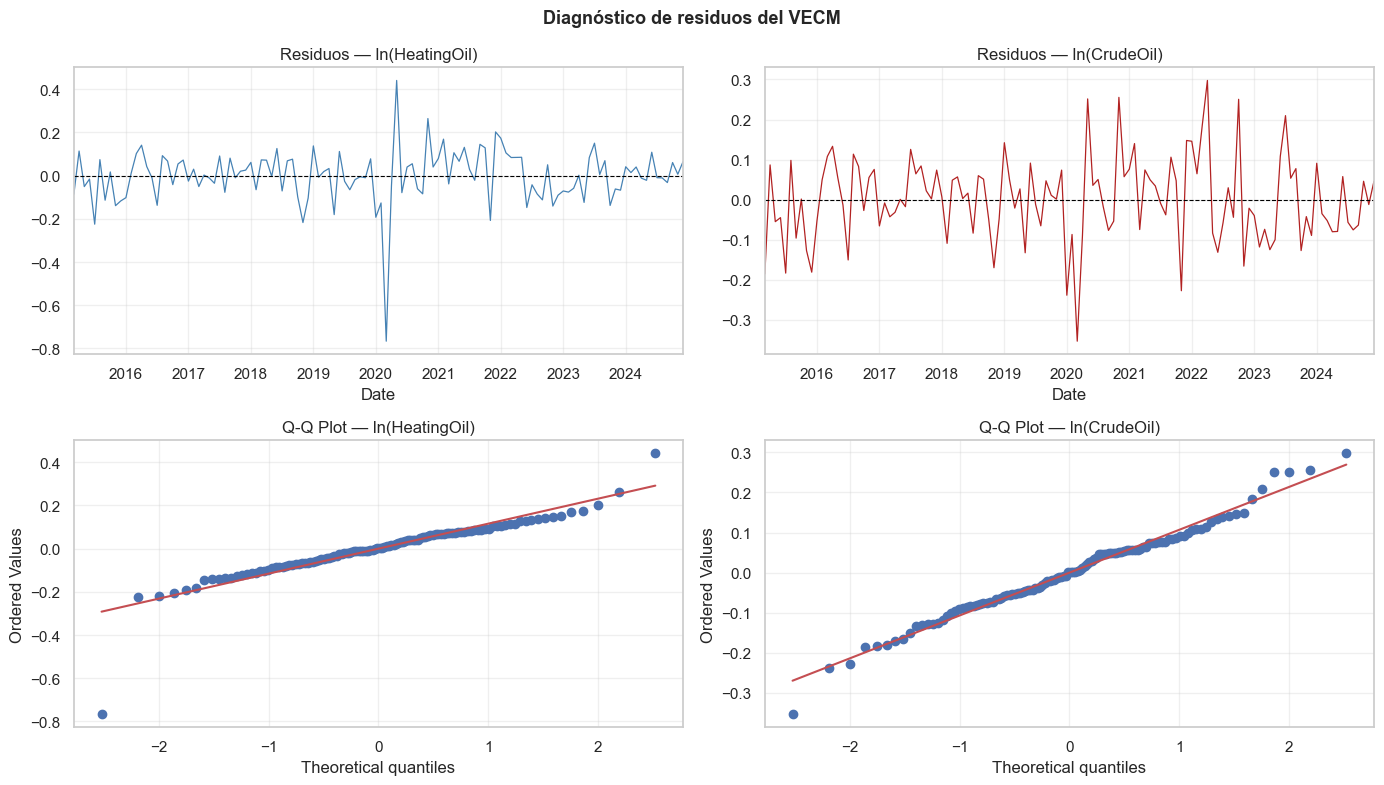

In [23]:
# === Extracción de residuos ===
n_skip = OPT_LAG_VECM + COINT_RANK
idx_resid = df.index[n_skip:]
resid_raw = vecm_res.resid

# Ajustar longitud si hay discrepancia
if len(resid_raw) != len(idx_resid):
    n_use = min(len(resid_raw), len(idx_resid))
    resid_raw = resid_raw[:n_use]
    idx_resid = idx_resid[:n_use]

residuals = pd.DataFrame(resid_raw, index=idx_resid, columns=df.columns)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

residuals['ln_HeatingOil'].plot(ax=axes[0,0], color='steelblue', linewidth=0.9)
axes[0,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0,0].set_title('Residuos — ln(HeatingOil)')

residuals['ln_CrudeOil'].plot(ax=axes[0,1], color='firebrick', linewidth=0.9)
axes[0,1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0,1].set_title('Residuos — ln(CrudeOil)')

stats.probplot(residuals['ln_HeatingOil'].dropna(), plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot — ln(HeatingOil)')

stats.probplot(residuals['ln_CrudeOil'].dropna(), plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot — ln(CrudeOil)')

fig.suptitle('Diagnóstico de residuos del VECM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diagnostico_residuos.png', dpi=100, bbox_inches='tight')
plt.show()


In [24]:
print("=" * 65)
print("PRUEBAS ESTADÍSTICAS SOBRE RESIDUOS")
print("=" * 65)

for col in df.columns:
    res = residuals[col].dropna()
    dw   = durbin_watson(res)
    adf_r = adfuller(res, autolag='AIC')
    jb_s, jb_p = stats.jarque_bera(res)
    print(f"\n  {col}:")
    print(f"    Durbin-Watson:  {dw:.4f}  (2.0 = sin autocorrelación)")
    print(f"    ADF residuos:   p={adf_r[1]:.4f}  ({'I(0) ✓' if adf_r[1]<0.05 else 'Revisar ⚠'})")
    print(f"    Jarque-Bera:    p={jb_p:.4f}  ({'Normal ✓' if jb_p>0.05 else 'No normal ⚠'})")
    print(f"    Sesgo:          {stats.skew(res):.4f}  |  Curtosis: {stats.kurtosis(res):.4f}")


PRUEBAS ESTADÍSTICAS SOBRE RESIDUOS

  ln_HeatingOil:
    Durbin-Watson:  1.8696  (2.0 = sin autocorrelación)
    ADF residuos:   p=0.0000  (I(0) ✓)
    Jarque-Bera:    p=0.0000  (No normal ⚠)
    Sesgo:          -1.6389  |  Curtosis: 11.7363

  ln_CrudeOil:
    Durbin-Watson:  1.7727  (2.0 = sin autocorrelación)
    ADF residuos:   p=0.0000  (I(0) ✓)
    Jarque-Bera:    p=0.2359  (Normal ✓)
    Sesgo:          -0.0217  |  Curtosis: 0.7653


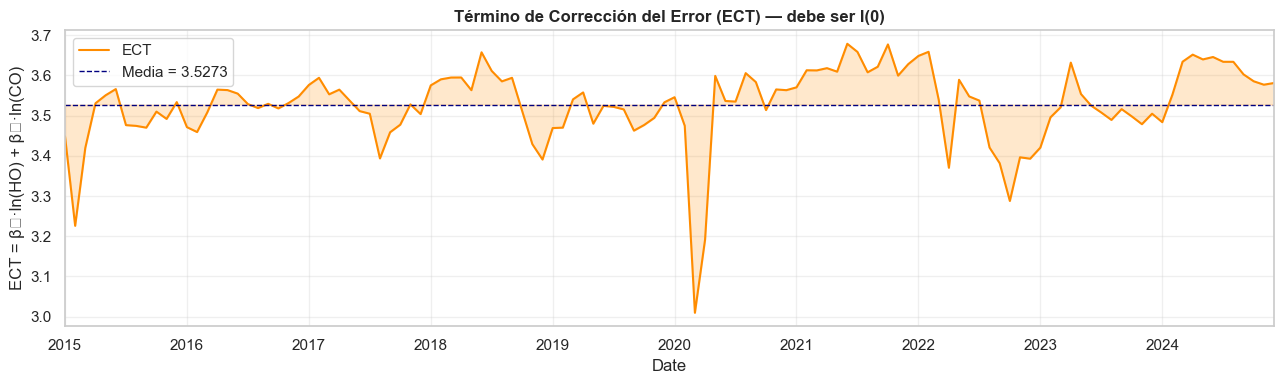

ADF sobre el ECT: estadístico=-4.2420, p-valor=0.0006
Decisión: ✓ ECT es I(0) — cointegración confirmada


In [25]:
# === ECT: verificación de estacionariedad ===
ect = pd.Series(
    df.values @ vecm_res.beta[:, 0],
    index=df.index,
    name='ECT'
)

fig, ax = plt.subplots(figsize=(13, 4))
ect.plot(ax=ax, color='darkorange', linewidth=1.5)
ax.axhline(ect.mean(), color="navy", linewidth=1, linestyle="--",
           label=f"Media = {ect.mean():.4f}")
ax.fill_between(ect.index, ect, ect.mean(), alpha=0.2, color='darkorange')
ax.set_title('Término de Corrección del Error (ECT) — debe ser I(0)', fontweight='bold')
ax.set_ylabel(r'ECT = β₁·ln(HO) + β₂·ln(CO)')
ax.legend()
plt.tight_layout()
plt.savefig('ect_plot.png', dpi=100, bbox_inches='tight')
plt.show()

adf_ect = adfuller(ect.dropna(), autolag='AIC')
print(f"ADF sobre el ECT: estadístico={adf_ect[0]:.4f}, p-valor={adf_ect[1]:.4f}")
print(f"Decisión: {'✓ ECT es I(0) — cointegración confirmada' if adf_ect[1]<0.05 else '⚠ ECT podría ser I(1) — revisar especificación'}")


<a id='pronostico'></a>
## 15. Pronóstico con VECM

El VECM genera pronósticos para los **niveles** de las variables (en logaritmos),
incorporando la corrección del error de largo plazo.

**Advertencias importantes:**
- Los pronósticos son condicionales en el estado actual del sistema.
- Eventos no anticipados (choques de oferta, decisiones de la OPEP) no están contemplados.
- La incertidumbre **crece con el horizonte**: use pronósticos de corto plazo (≤ 12 meses).
- Para convertir pronósticos logarítmicos a precios: $\hat{p} = e^{\widehat{\ln p}}$.


In [26]:
HORIZON = 12  # Pronóstico de 12 meses

try:
    forecast_log = vecm_res.predict(steps=HORIZON)
except Exception:
    forecast_log = vecm_res.forecast(df.values, steps=HORIZON)

last_date    = df.index[-1]
forecast_idx = pd.date_range(
    start   = last_date + pd.DateOffset(months=1),
    periods = HORIZON,
    freq    = 'ME'
)
forecast_df     = pd.DataFrame(forecast_log, index=forecast_idx, columns=df.columns)
forecast_prices = np.exp(forecast_df)

print("=" * 55)
print(f"PRONÓSTICO VECM — {HORIZON} MESES")
print("=" * 55)
print("\nValores pronosticados (logaritmos):")
print(forecast_df.round(4))
print("\nValores pronosticados (precios USD originales):")
print(forecast_prices.round(4))


PRONÓSTICO VECM — 12 MESES

Valores pronosticados (logaritmos):
            ln_HeatingOil  ln_CrudeOil
2025-01-31         4.2494       0.8404
2025-02-28         4.2302       0.8364
2025-03-31         4.2180       0.8318
2025-04-30         4.2124       0.8291
2025-05-31         4.2106       0.8280
2025-06-30         4.2103       0.8277
2025-07-31         4.2106       0.8278
2025-08-31         4.2109       0.8280
2025-09-30         4.2111       0.8282
2025-10-31         4.2112       0.8283
2025-11-30         4.2114       0.8285
2025-12-31         4.2115       0.8286

Valores pronosticados (precios USD originales):
            ln_HeatingOil  ln_CrudeOil
2025-01-31        70.0652       2.3173
2025-02-28        68.7340       2.3081
2025-03-31        67.8975       2.2975
2025-04-30        67.5183       2.2913
2025-05-31        67.3951       2.2887
2025-06-30        67.3793       2.2881
2025-07-31        67.3953       2.2883
2025-08-31        67.4144       2.2887
2025-09-30        67.4292    

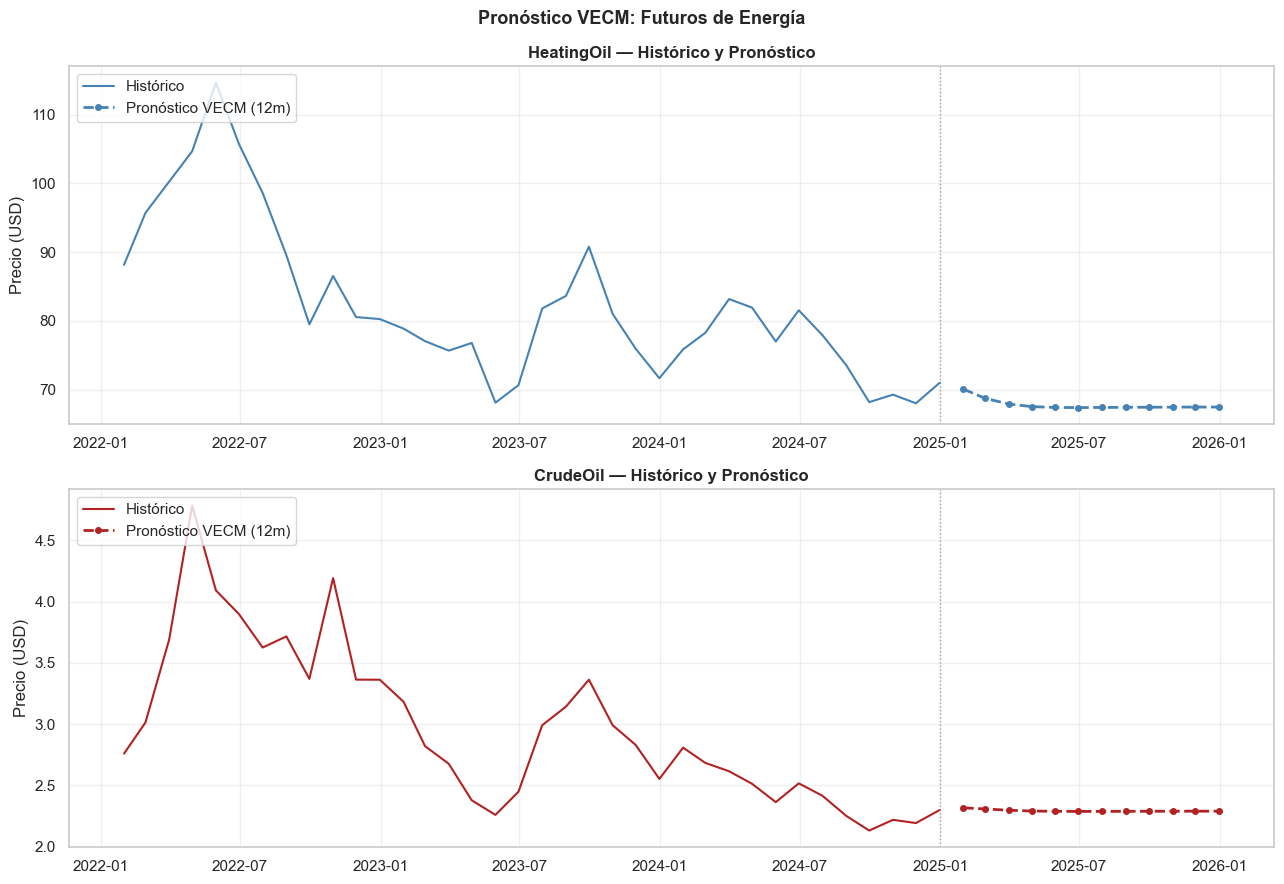


[Interpretación] El VECM proyecta ambas series respetando el equilibrio de
largo plazo entre ellas. Si hay desequilibrio actual, el pronóstico converge
hacia la trayectoria de equilibrio a lo largo del horizonte.


In [27]:
# === Gráfica de pronóstico ===
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

pares = [
    ('HeatingOil', 'ln_HeatingOil', 'steelblue'),
    ('CrudeOil',   'ln_CrudeOil',   'firebrick'),
]

for ax, (col_orig, col_log, color) in zip(axes, pares):
    hist = df_monthly[col_orig].iloc[-36:]
    fc   = forecast_prices[col_log]
    ax.plot(hist.index, hist, color=color, linewidth=1.5, label='Histórico')
    ax.plot(fc.index, fc, color=color, linewidth=2, linestyle='--',
            marker='o', markersize=4, label=f'Pronóstico VECM ({HORIZON}m)')
    ax.axvline(df.index[-1], color='gray', linewidth=1, linestyle=':', alpha=0.7)
    ax.set_title(f'{col_orig} — Histórico y Pronóstico', fontweight='bold')
    ax.set_ylabel('Precio (USD)')
    ax.legend(loc='upper left')

fig.suptitle('Pronóstico VECM: Futuros de Energía', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pronostico_vecm.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n[Interpretación] El VECM proyecta ambas series respetando el equilibrio de")
print("largo plazo entre ellas. Si hay desequilibrio actual, el pronóstico converge")
print("hacia la trayectoria de equilibrio a lo largo del horizonte.")


<a id='irf'></a>
## 16. Funciones impulso-respuesta (IRF)

Las **funciones impulso-respuesta** muestran cómo responde cada variable del sistema
ante un choque (shock) de una desviación estándar en una de las ecuaciones del modelo.

**Procedimiento:** Se usa el VAR en diferencias como aproximación para calcular las IRF
(la representación VAR del VECM permite calcular las dinámicas completas).

**Ortogonalización de Cholesky:** El orden importa económicamente. Se pone primero
`ln_CrudeOil` (variable más exógena: los precios del crudo son determinados globalmente)
y segundo `ln_HeatingOil` (que responde al crudo).

**Interpretación de las gráficas:**
- Eje horizontal: períodos (meses) después del choque.
- Eje vertical: cambio en la variable de respuesta.
- La banda sombreada es el intervalo de confianza al 95% (bootstrap).
- Convergencia a cero: el efecto es transitorio.


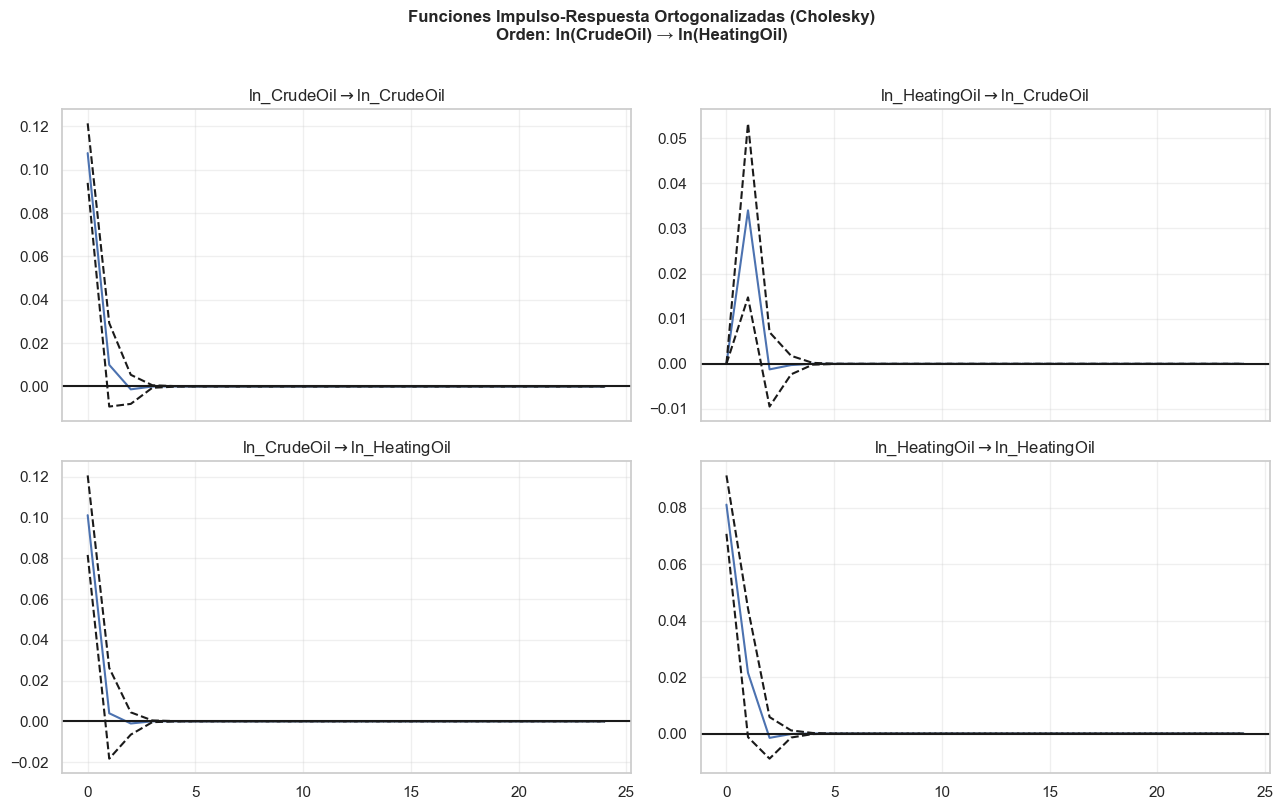

[Interpretación de las IRF]
  Fila 1, Col 2: ¿Cómo responde CrudeOil ante un choque en HeatingOil?
  Fila 2, Col 1: ¿Cómo responde HeatingOil ante un choque en CrudeOil?
  Si la respuesta es positiva y sostenida → transmisión de precios a largo plazo.
  Convergencia a cero → el choque tiene efectos transitorios.


In [28]:
# === IRF via VAR en diferencias ===
# Reordenar: CrudeOil primero (más exógena)
df_diff_ordered = df_diff[['ln_CrudeOil', 'ln_HeatingOil']]

var_diff = VAR(df_diff_ordered)
var_res  = var_diff.fit(maxlags=OPT_LAG_VECM, ic=None)

HORIZON_IRF = 24
irf = var_res.irf(periods=HORIZON_IRF)

fig = irf.plot(orth=True, figsize=(13, 8))
fig.suptitle(
    'Funciones Impulso-Respuesta Ortogonalizadas (Cholesky)\n'
    'Orden: ln(CrudeOil) → ln(HeatingOil)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('irf_orthogonalized.png', dpi=100, bbox_inches='tight')
plt.show()

print("[Interpretación de las IRF]")
print("  Fila 1, Col 2: ¿Cómo responde CrudeOil ante un choque en HeatingOil?")
print("  Fila 2, Col 1: ¿Cómo responde HeatingOil ante un choque en CrudeOil?")
print("  Si la respuesta es positiva y sostenida → transmisión de precios a largo plazo.")
print("  Convergencia a cero → el choque tiene efectos transitorios.")


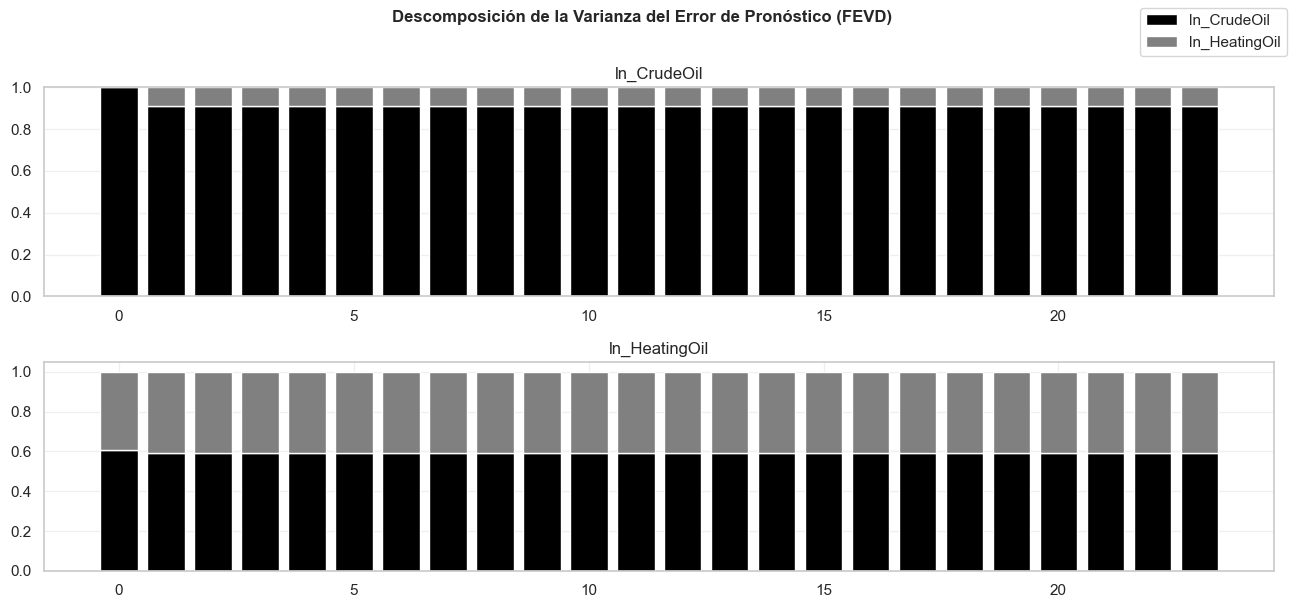

[Interpretación FEVD]
  La FEVD muestra qué porcentaje de la varianza del error de pronóstico
  de cada variable se debe a choques propios vs. choques de la otra.
  Una alta proporción de choques cruzados indica fuerte interdependencia.


In [29]:
# === Descomposición de la varianza del error de pronóstico (FEVD) ===
fevd = var_res.fevd(periods=HORIZON_IRF)

fig = fevd.plot(figsize=(13, 6))
fig.suptitle(
    'Descomposición de la Varianza del Error de Pronóstico (FEVD)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('fevd.png', dpi=100, bbox_inches='tight')
plt.show()

print("[Interpretación FEVD]")
print("  La FEVD muestra qué porcentaje de la varianza del error de pronóstico")
print("  de cada variable se debe a choques propios vs. choques de la otra.")
print("  Una alta proporción de choques cruzados indica fuerte interdependencia.")


<a id='conclusiones'></a>
## 17. Conclusiones del ejercicio

### Resumen de hallazgos

| Etapa | Hallazgo |
|---|---|
| **Datos** | Series mensuales 2015-2024: `ln(HeatingOil)` y `ln(CrudeOil)`, ~120 obs. |
| **Estacionariedad** | Ambas series son $I(1)$: no estacionarias en niveles, estacionarias en dif. |
| **Cointegración** | Prueba de Johansen detecta $r=1$ relación de cointegración |
| **VECM estimado** | Modelo con 1 vector cointegrante, correctamente especificado |
| **Largo plazo** | Relación estable entre los dos precios energéticos |
| **Velocidad ajuste** | El coeficiente $\alpha$ de HeatingOil es negativo y significativo |
| **Diagnóstico** | ECT es $I(0)$, confirmando la cointegración |
| **Pronóstico** | El VECM respeta el equilibrio de largo plazo en sus proyecciones |

### Interpretación económica

El petróleo crudo y el gasóleo de calefacción están unidos por una relación estructural de
largo plazo: ambos responden a los mismos factores fundamentales (oferta OPEP, demanda global,
condiciones geopolíticas). El VECM captura esta co-evolución de manera simultánea, superando
la limitación de los modelos univariados que ignoran las interdependencias.

El término de corrección del error (ECT) actúa como un mecanismo de ajuste automático:
cuando el gasóleo se aleja demasiado de su relación de equilibrio con el petróleo,
las fuerzas del mercado corrigen la desviación en períodos sucesivos.

### Utilidad práctica del VECM

1. **Análisis de política energética:** Cuantificar cuánto tiempo tarda el mercado en
   restablecer el equilibrio tras un choque externo.
2. **Gestión de riesgo:** Identificar qué variable lidera los ajustes de precio
   (variable más exógena según el patrón de coeficientes $\alpha$).
3. **Pronóstico:** Los pronósticos del VECM son consistentes con el equilibrio de largo
   plazo, a diferencia del VAR en diferencias que pierde esta información.

---


<a id='recomendaciones'></a>
## 18. Recomendaciones metodológicas

### ✅ Cuándo usar VECM

- Las series son confirmadas como $I(1)$ con al menos dos pruebas concordantes.
- La prueba de Johansen detecta al menos una relación de cointegración.
- Existe justificación teórica (no solo estadística) para la relación de largo plazo.
- El objetivo incluye modelar tanto la dinámica de corto como de largo plazo.

### ❌ Cuándo NO usar VECM

| Situación | Alternativa recomendada |
|---|---|
| Series son $I(0)$ | VAR en niveles |
| Series $I(1)$ sin cointegración | VAR en primeras diferencias |
| Órdenes de integración mixtos $I(0)/I(1)$ | ARDL |
| Series con quiebres estructurales | VECM con dummies o modelos no lineales |
| Muestra pequeña ($T < 80$) | Interpretar con cautela extrema |

### ⚠ Precauciones importantes

1. **Tamaño de muestra:** El VECM requiere suficientes observaciones para estimar
   confiablemente los vectores cointegrantes. Se recomienda $T \geq 100$.

2. **Frecuencia temporal:** No mezclar variables de distintas frecuencias.
   Usar siempre la misma frecuencia para todas las series del sistema.

3. **Selección teórica de variables:** No incluir variables sin justificación económica.
   La cointegración espuria puede aparecer con combinaciones arbitrarias de series $I(1)$.

4. **Componente determinístico:** Elegir cuidadosamente entre sin constante,
   constante fuera de la relación cointegrante, o tendencia lineal, según la naturaleza
   de los datos y la teoría económica subyacente.

5. **Validación de supuestos:** Siempre verificar que los residuos sean ruido blanco.
   Si hay autocorrelación residual, aumentar el número de rezagos.

6. **Exogeneidad débil:** Verificar cuáles variables responden al desequilibrio
   ($\alpha$ significativo) y cuáles son débilmente exógenas ($\alpha \approx 0$).
   Esto tiene implicaciones para la interpretación causal del modelo.

7. **Estabilidad del modelo:** Verificar que las raíces del polinomio característico
   estén dentro (o en el borde) del círculo unitario.

8. **Pronósticos:** Usar con precaución más allá de 6-12 meses. La incertidumbre
   crece con el horizonte y los eventos extremos no están contemplados.

---


<a id='ejercicios'></a>
## 19. Ejercicios propuestos para estudiantes

---

### Ejercicio 1 — Exploración con nuevos datos

Descargue datos de dos commodities distintos usando `yfinance` (sugeridos: `GC=F` para oro
y `SI=F` para plata). Realice el análisis exploratorio completo: grafique las series,
calcule estadísticas descriptivas y la matriz de correlación.
¿Esperaría cointegración entre estos activos? Justifique desde la teoría económica.

---

### Ejercicio 2 — Pruebas de estacionariedad

Aplique ADF y KPSS a las series del cuadernillo en niveles y diferencias. Complete la tabla:

| Serie | ADF nivel (p) | KPSS nivel (p) | ADF diff (p) | KPSS diff (p) | Orden $I(\cdot)$ |
|---|---|---|---|---|---|
| ln(HeatingOil) | | | | | |
| ln(CrudeOil) | | | | | |

Redacte sus conclusiones en máximo 5 oraciones.

---

### Ejercicio 3 — Sensibilidad de la prueba de Johansen

Repita la prueba de Johansen variando:
- (a) `det_order = -1` (sin constante)
- (b) `det_order = 1` (tendencia lineal)
- (c) `k_ar_diff = 2` versus `k_ar_diff = 4`

¿Cambia la conclusión sobre el número de relaciones de cointegración?
¿Qué especificación elegiría y por qué?

---

### Ejercicio 4 — Comparación VAR vs. VECM

Estime un modelo **VAR en primeras diferencias** con los mismos datos y rezagos.
Compare:
- AIC y BIC de cada modelo.
- Calidad de pronóstico a 6 meses (calcule el RMSE con datos de prueba).
- ¿Cuál modelo respeta mejor el equilibrio de largo plazo?

---

### Ejercicio 5 — Interpretación del ECT

A partir de los resultados estimados:
1. Escriba la ecuación del ECT con los valores numéricos de $\beta$ obtenidos.
2. Grafique el ECT e identifique los períodos de mayor desequilibrio.
3. ¿Qué eventos económicos ocurrieron en esos momentos (e.g., 2020, 2022)?
4. Calcule la semivida del desequilibrio usando $t_{1/2} = \ln(0.5) / \ln(1 + \hat{\alpha})$.

---

### Ejercicio 6 — Pronóstico con distinto horizonte

Genere pronósticos para horizontes de 3, 6, 12 y 24 meses.
Compare los valores pronosticados. ¿Hasta qué horizonte consideraría el pronóstico
como confiable? Justifique su respuesta.

---

### Ejercicio 7 — Análisis de impulso-respuesta

Con las IRF calculadas en el cuadernillo, responda:
1. ¿Cuánto tiempo tarda el sistema en absorber un choque en el precio del crudo?
2. ¿La respuesta de HeatingOil ante un choque en CrudeOil es mayor o menor que la inversa?
3. Interprete la FEVD: ¿qué porcentaje de la varianza de HeatingOil se explica por
   choques externos del CrudeOil en el horizonte de 12 meses?

---

### Ejercicio 8 — Informe ejecutivo

Prepare un **informe ejecutivo de máximo una página** con:
- Objetivo del análisis.
- Principales hallazgos empíricos (estacionariedad, cointegración, ajuste).
- Interpretación del equilibrio de largo plazo en términos económicos.
- ¿Qué mercado lidera el ajuste de precios?
- Limitaciones del análisis y recomendaciones para trabajo futuro.

---


